##     Case study iMM904 curation
 Using the iMM904 model as a case study, we have used Thermo-Flux and did the few manual curation steps to show how models can be converted into a combined thermodynamic-stoichiometric model.
Here, we present the steps that required manual attention when following the protocol described in the publication. "
    

In [ ]:
import cobra
from cobra import Model, Reaction, Metabolite
import sys
from thermo_flux.core.metabolite import ThermoMetabolite
import thermo_flux
from thermo_flux.io import load_excel as ex
from thermo_flux.core.model import ThermoModel, ThermoReaction
from equilibrator_api import  Q_
import pandas as pd
from thermo_flux.io import load_gams as gs
from thermo_flux.io import helper_load as hl
from thermo_flux.utils.vis import compare_met
import numpy as np
import gurobipy as  gp
from gurobipy import GRB


import seaborn as sns
import matplotlib.pyplot as plt


Import sbml model from BiGG

In [2]:
from cobra.io import load_json_model
model=load_json_model('iMM904.json')

#set objective to biomass
model.objective = model.reactions.BIOMASS_SC5_notrace
model.reactions.EX_co2_e.id='co2_EX'
model.reactions.EX_o2_e.id='o2_EX'
model.reactions.EX_etoh_e.id='etoh_EX'
model.repair()

for rxn in model.reactions:
    if 'EX_' not in rxn.id:
        rxn.lower_bound=-500 if rxn.lower_bound==-999999.0 else rxn.lower_bound
        rxn.upper_bound=500 if rxn.upper_bound==999999.0 else rxn.upper_bound
    else:
        rxn.lower_bound=-500 if rxn.lower_bound==-999999.0 else rxn.lower_bound
        rxn.upper_bound=500 if rxn.upper_bound==999999.0 else rxn.upper_bound
       # print(rxn.id,rxn.lower_bound,rxn.upper_bound)

#reset O2 exchange bound
model.optimize().to_frame().loc['BIOMASS_SC5_notrace']['fluxes']
model.reactions.o2_EX.bounds=(-500,0)

print(model.optimize().to_frame().loc['BIOMASS_SC5_notrace']['fluxes'])
model.optimize().to_frame().loc[[rxn.id for rxn in model.boundary]]



Set parameter Username
Set parameter LicenseID to value 2594640
Academic license - for non-commercial use only - expires 2025-12-03
0.9748814206733547


,fluxes,reduced_costs
EX_epistest_SC_e,0.0,-96.275549
EX_epist_e,0.0,-1.676719
EX_ergst_e,0.0,-1.722387
EX_ergstest_SC_e,0.0,-96.321217
EX_13BDglcn_e,0.0,-0.196130
...,...,...
EX_xyl__D_e,0.0,-0.163442
EX_xylt_e,0.0,-0.176421
EX_rib__D_e,0.0,-0.174979
EX_zymst_e,0.0,-1.620476


Solver status is 'infeasible'.


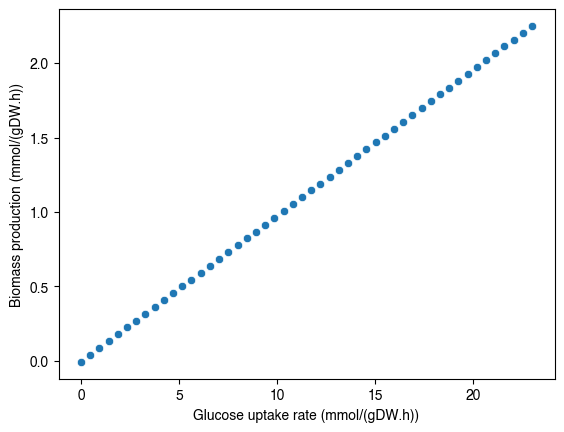

In [3]:
#plot biomass yield for stoichiometric model
#GUR_range=[-0.25, -0.57, -0.6 , -1.1 , -1.67, -2.14, -2.22, -2.83, -3.24, -3.7, -4.67, -5.44, -7.62, -8.09, -8.33, -10.23, -13.18, -15.7, -22.42]
GUR_range = np.linspace(-0, -23, 50)

GUR_plot_range=[-x for x in GUR_range]
biomass_flux=[]
etoh_flux=[]
o2_flux=[]
co2_flux=[]
for GUR in GUR_range:
    model.reactions.EX_glc__D_e.upper_bound=0
    model.reactions.EX_glc__D_e.lower_bound=GUR
    sol = model.optimize()
    #add values to list
    biomass_flux.append(sol.fluxes.loc['BIOMASS_SC5_notrace'])
    etoh_flux.append(sol.fluxes.loc['etoh_EX'])
    o2_flux.append(sol.fluxes.loc['o2_EX'])
    co2_flux.append(sol.fluxes.loc['co2_EX'])
#plot biomass vs GUR in a scatter plot
sns.scatterplot(x=GUR_plot_range,y=biomass_flux)
plt.xlabel('Glucose uptake rate (mmol/(gDW.h))')
plt.ylabel('Biomass production (mmol/(gDW.h))')
fba_flux=pd.DataFrame({'biomass_EX':biomass_flux,'etoh_EX':etoh_flux,'o2_EX':o2_flux,'co2_EX':co2_flux},index=GUR_range)
# plt.savefig('Figures/growth_stoichio_only.png',dpi=300)
# model.optimize().to_frame().loc['BIOMASS_SC5_notrace']/model.optimize().to_frame().loc['EX_glc__D_e']

### Step 1 - Physical and Biochemical parameters

In [4]:
tmodel=ThermoModel(model,split_biomass=True, add_charge_exchange= True)

Initializing component contribution object...
cxcalc is not installed, operating in read-only mode. A local cache may be loaded, but no compounds can be created. Install cxcalc and obtain a ChemAxon license to enable compound creation.
Loading compounds from iMM904_compound.sqlite
added reaction:  biomass_ce: biomass_c <=> biomass_e
added reaction:  biomass_EX: biomass_e <=> 
added reaction:  charge_ce: charge_e <=> charge_c
added reaction:  EX_charge: charge_e <=> 
added reaction:  charge_cm: charge_m <=> charge_c
added reaction:  charge_cx: charge_x <=> charge_c
added reaction:  charge_cr: charge_r <=> charge_c
added reaction:  charge_cv: charge_v <=> charge_c
added reaction:  charge_cg: charge_g <=> charge_c
added reaction:  charge_cn: charge_n <=> charge_c


In [5]:
#define the biochemical parameters of the model

tmodel.phi={'ec': Q_(-0.06,'volt'), 'cm': Q_(-0.16,'volt'),'cx':Q_(0,'volt'),'cr':Q_(0,'volt'),'cv':Q_(0,'volt'),'cg':Q_(0,'volt'),'cn':Q_(0,'volt')}
tmodel.pH={'c':Q_(7),'e':Q_(5),'m':Q_(7.4),'r':Q_(7),'v':Q_(5.5),'g':Q_(7),'x':Q_(7),'n':Q_(7)} #On the intracellular pH of baker’s yeast(r), Martinez-Munoz et al. 2008(v), Juan Llopis et al 1998 (g), 7 is default pH

##from first version
# tmodel.pH={'c':Q_(7.2),'e':Q_(5),'m':Q_(7.4),'r':Q_(7.4),'v':Q_(7.4),'g':Q_(7.4),'x':Q_(7.4),'n':Q_(7.4)}
# tmodel.phi={'ec': Q_(-0.06,'volt'), 'cm': Q_(-0.16,'volt'),'cx':Q_(-0.16,'volt'),'cr':Q_(-0.16,'volt'),'cv':Q_(-0.16,'volt'),'cg':Q_(-0.16,'volt'),'cn':Q_(-0.16,'volt')}
#assuming same membrane potential between cytosol and organelles than c and mitochondria ?

#change max drGcalc_drGt
tmodel._max_drG=Q_(1e6,'kJ/mol') #max is already 1e8 shouldnt need to change


### Step 2 - Definition of metabolites

In [6]:
tmodel.get_compounds(search = True)

[████████████████████████████████████████] 1236/1236 charge_n                                                                    



[<ThermoMetabolite biomass_c at 0x76fd69bd58a0>,
 <ThermoMetabolite biomass_e at 0x76fd69bd5330>]

In [7]:
#define biomass parameters 
#if the biomass formula is not automatically calcualted it's important to specifiy the hydrogen atoms in biomass to ensure correct proton balancing 
tmodel.metabolites.biomass_c.formula = 'H67'
tmodel.metabolites.biomass_e.formula = 'H67'

#manually define charge of cytochrome C so electron movement is correctly calcualted
tmodel.metabolites.focytc_m.charge = 2
tmodel.metabolites.focytc_m.redox= True #define as redox metabolite 
tmodel.metabolites.ficytc_m.charge = 3
tmodel.metabolites.ficytc_m.redox = True

### Step 3 - metabolites formation energies

When specifying the value of `dfGprime` for the biomass metabolite, we should plug in the values in units of **J/gDW**. This differs from all the other reactions in the model, for which values of **kJ/mol** are used.

The reason for this discrepancy has to do with the units of the fluxes.

For a normal reaction:
$g_{diss, rxn} = \Delta_rG \times v = (kJ/mol) \times (mmol/gDW/h) = (10^3 J/mol) \times (10^{-3} mol/gDW/h) = J/gDW/h$

For the biomass reaction:
$g_{diss, bio} = \Delta_fG_{bio} \times \mu = (J/gDW) \times (gDW/gDW/h) = J/gDW/h $

Since thermoflux handles all reactions the same when determining the gibbs energy dissipation rate (multiplying $v$ by $\Delta_rG$), we have to **pretend** that the biomass formation energy has units of kJ/mol. E.g:
`tmodel.metabolites.biomass_c.dfGprime = Q_(701.767, "kJ/mol")` (where 701.767 is the formation energy of E.coli biomass at cytosolic pH, in units of J/gDW)

In [8]:
#define biomass properties
tmodel.reactions.BIOMASS_SC5_notrace.id='biomass_c' #update biomass reaction name for convenience

tmodel.metabolites.biomass_c.dfG0 = Q_(-3.04,'kJ/mol')*1000 #From Battley 1991, *1000 for mmol flux units (actual units here are J/gDW)
tmodel.metabolites.biomass_e.dfG0 = Q_(-3.04,'kJ/mol')*1000


### Step 4 - Transporters

In [9]:
#idenfity transporters where the transported metabolite is empty
#these could either be redox reactions or proton pumps just moving electrons (charge) and protons 
#or they could be transporters with chemcial transformation during the transport process
for reaction in tmodel.reactions:
    if len(reaction.compartments) > 1:
        if thermo_flux.tools.drg_tools.calc_transported_mets(reaction) == {}:
            print(reaction.id, reaction, thermo_flux.tools.drg_tools.calc_transported_mets(reaction))


ASPOcm ASPOcm: asp__L_c + fad_m --> fadh2_m + h_c + iasp_c {}
ATPS ATPS: atp_c + h2o_c --> adp_c + h_e + pi_c {}
DHORD4i DHORD4i: dhor__S_c + q6_m --> orot_c + q6h2_m {}
DOLPMTcer DOLPMTcer: dolp_c + gdpmann_c --> dolmanp_r + gdp_c {}
DXHPScm DXHPScm: h2o_c + q6_m + spmd_c --> 13dampp_c + 4abutn_c + q6h2_m {}
D_LACDcm D_LACDcm: 2.0 ficytc_m + lac__D_c --> 2.0 focytc_m + pyr_c {}
FDNG FDNG: for_c + h_c + q6_m --> co2_c + q6h2_m {}
FRDcm FRDcm: fadh2_m + fum_c --> fad_m + succ_c {}
L_LACD2cm L_LACD2cm: 2.0 ficytc_m + lac__L_c --> 2.0 focytc_m + pyr_c {}
NADH2_u6cm NADH2_u6cm: h_c + nadh_c + q6_m --> nad_c + q6h2_m {}


In [10]:
#DOLPMTcer involved chemcial transformation of dolp. We assume transport of dolmanp for thermodynamic calcualtion
tmodel.reactions.DOLPMTcer.transported_mets = {tmodel.metabolites.dolmanp_r: -1}

In [11]:
## add proton transport reactions ##the directions are constrained by pH gradients

tmodel.add_proton_exchange()

added reaction:  H_cm: h_m <=> h_c
added reaction:  H_cx: h_x <=> h_c
added reaction:  H_cr: h_r <=> h_c
added reaction:  H_cv: h_v <=> h_c
added reaction:  H_cg: h_g <=> h_c
added reaction:  H_cn: h_n <=> h_c


In [12]:
## add transporter variants for all phosphate transporters

for rxn in [r for r in tmodel.reactions if len(r.compartments) > 1 and any(m.id.split('_')[0] == 'pi' for m in r.metabolites)
            and not any(m.id.split('_')[0] == 'atp' for m in r.metabolites )]:
    new_reactions = thermo_flux.tools.drg_tools.add_transporter_varaints(rxn,balance_charge=True,add_charge_neutral = True, round_dp=2)
    if new_reactions is not None:
        if len(new_reactions) > 0:
            for new_reaction in new_reactions:
                print(new_reaction)

PIt2m0: 1.83 h_c + pi_c <=> 2.0 h_m + pi_m
PIt2v0: 1.83 h_c + pi_c <=> 1.14 h_v + pi_v


### Step 5 - charge and proton balancing

In [13]:
for rxn in tmodel.reactions:
    thermo_flux.tools.drg_tools.reaction_balance(rxn, balance_charge=True, balance_mg=False)

manually curate all reactions that gave a warning

In [14]:
#ATPS3v is vacuolar ATP synthase transporting three protons per ATP
tmodel.reactions.ATPS3v.transported_h = {'v': 3.0, 'c': -3.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.ATPS3v, balance_charge=True, balance_mg=False)


In [15]:
tmodel.reactions.ASPOcm.transported_h= {'m': 2.0, 'c': -2.0}
tmodel.reactions.ASPOcm.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.ASPOcm, balance_charge=True, balance_mg=False)

In [16]:
tmodel.reactions.ATPS.transported_h={'c':-1,'e':1}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.ATPS, balance_charge=True, balance_mg=False)

In [17]:
#DHORD4i
tmodel.reactions.DHORD4i.transported_h = {'m': 2.0, 'c': -2.0}
tmodel.reactions.DHORD4i.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.DHORD4i, balance_charge=True, balance_mg=False)

In [18]:
#DXHPScm is fine

In [19]:
# D_LACDcm
tmodel.reactions.D_LACDcm.transported_charge= {'m': 2.0, 'c': -2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.D_LACDcm, balance_charge=True, balance_mg=False)

In [20]:
##FDNG
tmodel.reactions.FDNG.transported_h = {'m': 2.0, 'c': -2.0}
tmodel.reactions.FDNG.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.FDNG, balance_charge=True, balance_mg=False)

In [21]:
#FRDcm ## opposite then others h transport rxn we did until now
tmodel.reactions.FRDcm.transported_h = {'m': -2.0, 'c': 2.0}
tmodel.reactions.FRDcm.transported_charge= {'m': 2.0, 'c': -2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.FRDcm, balance_charge=True, balance_mg=False)

In [22]:
# L_LACD2cm
tmodel.reactions.L_LACD2cm.transported_charge= {'m': 2.0, 'c': -2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.L_LACD2cm, balance_charge=True, balance_mg=False)

In [23]:
# NADH2_u6cm
tmodel.reactions.NADH2_u6cm.transported_h = {'m': 2.0, 'c': -2.0}
tmodel.reactions.NADH2_u6cm.transported_charge= {'m': -2.0, 'c': 2.0}
thermo_flux.tools.drg_tools.reaction_balance(tmodel.reactions.NADH2_u6cm, balance_charge=True, balance_mg=False)

### Step 6 - Calculation of Gibbs energy of reactions
Add thermodynamic constraints and parameters

In [24]:
#change max flux to 500 for all reactions

tmodel.reactions.get_by_id("biomass_EX").bounds = (0,500)
tmodel.reactions.get_by_id("biomass_c").bounds = (0,500)
tmodel.reactions.get_by_id("biomass_ce").bounds = (0,500)


for rxn in tmodel.reactions:
    rxn.lower_bound = -500 if rxn.lower_bound == -1000 else rxn.lower_bound
    rxn.upper_bound = 500 if rxn.upper_bound == 1000 else rxn.upper_bound
tmodel.objective = tmodel.reactions.biomass_EX

In [25]:
tmodel.update_thermo_info(fit_unknown_dfG0=False,search=True)


Identifying compounds...


[████████████████████████████████████████] 1244/1244 Mg_n                                                                                                                                                                                                                                                                                                    

Estimating dfG0'...


ficytc_m 0 kilojoule / mole
focytc_m 0 kilojoule / mole
biomass_c 0 kilojoule / mole
biomass_e 0 kilojoule / mole
[████████████████████████████████████████] 1244/1244 Mg_n                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

Estimating drG0'...


[████████████████████████████████████████] 1595/1595 PIt2v0                                                                                                                                                                                                                                                                                                                     



In [26]:
for met in tmodel.metabolites:
    if met.ignore_conc:
        print(met.id,met.ignore_conc)

h2o_c True
h2o_e True
h2o_g True
h2o_m True
h2o_n True
h2o_r True
h2o_v True
h2o_x True
h_c True
h_e True
h_g True
h_m True
h_n True
h_r True
h_v True
h_x True
oh1_c True
oh1_m True
biomass_c True
biomass_e True
charge_c True
charge_e True
charge_m True
charge_x True
charge_r True
charge_v True
charge_g True
charge_n True


In [27]:
#ignore snd for charge ?
for rxn in tmodel.reactions:
    if 'charge' in rxn.id and 'EX' not in rxn.id:#charge reactions are constrained by 2nd law 
        print(rxn.id,rxn.ignore_snd)
        rxn.ignore_snd=True
        print(rxn.id,rxn.ignore_snd)
        


#tmodel.reactions.EX_charge.ignore_snd=True

charge_ce False
charge_ce True
charge_cm False
charge_cm True
charge_cx False
charge_cx True
charge_cr False
charge_cr True
charge_cv False
charge_cv True
charge_cg False
charge_cg True
charge_cn False
charge_cn True


### Step 7 - Establishment of the thermodynamic-stoichiometric solution space
Note : In our curation of the iMM904 model, due to the limited information available for the membrane potential of organelles, we chose to allow the free leakage of ions (charges) across the membrane. 
Allowing free movement of charges between compartments prevents over-constraining the model to potentially incorrect information.
For more detailed analysis of charge transport or models where more information is available on membrane physiology then a constraint on the second law could be added for these charge transport reactions.  

In [28]:
##x r v g n
tmodel.reactions.H_cm.ignore_snd=False
tmodel.reactions.H_cv.ignore_snd=False
tmodel.reactions.H_cx.ignore_snd=False
tmodel.reactions.H_cr.ignore_snd=False
tmodel.reactions.H_cg.ignore_snd=False
tmodel.reactions.H_cn.ignore_snd=False


In [29]:
# add the TFBA variables to the model
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = False, sigmac_limit = (5000/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
tmodel.m.update()

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10


In [30]:
# thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA_ENS_8.sol', ignore_vars=['all'],fix_vars=['qm','fluxes'],fix='start')


In [31]:
tmodel.mvars['v'][0][tmodel.reactions.index('biomass_EX')].lb=0.1

In [32]:
tmodel.m.params.NonConvex=2
tmodel.m.params.IntFeasTol=1e-6
tmodel.m.params.OptimalityTol=1e-6
tmodel.m.params.TimeLimit=60*60*10
tmodel.m.optimize()


Set parameter IntFeasTol to value 1e-06
Set parameter TimeLimit to value 36000
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 15733 rows, 12900 columns and 351055 nonzeros
Model fingerprint: 0x8a5eabee
Model has 1 general constraint
Variable types: 11305 continuous, 1595 integer (1595 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-01, 1e+06]
  RHS range        [7e-15, 1e+06]
Presolve removed 8347 rows and 6258 columns
Presolve time: 0.81s
Presolved: 7386 rows, 6642 columns, 292584 nonzeros
Variable types: 5400 continuous, 1242 integer (1242 binary)

Root relaxation: objective 2.609593e+00, 10697 iterations, 2.40 seconds (8.00 work units)
Total elapsed time = 8.53s (DegenMoves)

    Nodes    |    C

In [ ]:
tmodel.m.write('fixed_dir_firstTFBA.sol')

In [34]:
# add the TFBA variables to the model
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = True, sigmac_limit = (3700/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
tmodel.m.update()
tmodel.m.params.timelimit=60*5

GUR_range = np.linspace(-0, -23, 50)

thermo_flux.solver.gurobi.variable_scan(tmodel, GUR_range, var = tmodel.mvars['v'][0][tmodel.reactions.index(tmodel.reactions.get_by_id('EX_glc__D_e'))]) # here we get the index for the glucose uptake reaction and use this to index the v variable in the gurobi model
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol',ignore_vars=['all'],fix_vars=['qm'],fix='bound') #fix the drG error term to that from the initial TFBA to speed up optimisations

tmodel.m.optimize()

fluxes_gdiss = thermo_flux.solver.gurobi.multi_scenario_sol(tmodel,var = 'v') 
fluxes_gdiss= pd.DataFrame(fluxes_gdiss[0].T, index = [rxn.id for rxn in tmodel.reactions])

Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 300
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 15733 rows, 12900 columns and 351055 nonzeros
Model fingerprint: 0xd350b976
Model has 1 general constraint
Variable types: 11305 continuous, 1595 integer (1595 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]

Solving a multi-scenario model with 50 scenarios...

Presolve removed 10935 rows and 8602 columns
Presolve time: 0.10s
Presolved: 4801 rows, 4348 columns, 14759 nonzeros
Presolved model has 50 scenario(s)
Variable types: 3336 continuous, 1012 integer (1012 binary)

Root relaxation: objective 2.608

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Text(0, 0.5, 'Biomass production rate (mmol/(gDW.h))')

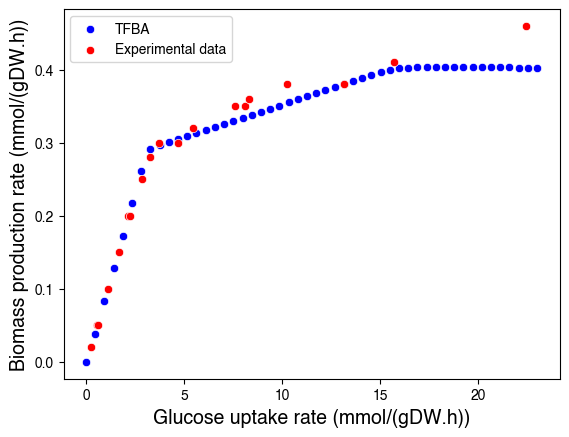

In [ ]:
#plot biomass yield for stoichiometric model with balanced reactions and pH specified
df_data2 = pd.read_csv('plotting_Yeast_ALL_experimental_data.csv',index_col=0)
df_data2['regression'].fillna('Not fitted',inplace=True)
df_data2['regression'].replace('yes', 'Fitted', inplace=True)
df_data2.rename(columns={'regression':'Exp. data'}, inplace=True)
#rename index in Condition
df_data2.index.rename('Condition', inplace=True)

GUR_plot_range=[-x for x in GUR_range]
#plot biomass vs GUR in a scatter plot

sns.scatterplot(x=GUR_plot_range,y=fluxes_gdiss.loc['biomass_EX'],color='b',label='TFBA')
# sns.scatterplot(x=GUR_plot_range,y=tbiomass_flux,color='b',label='FBA and balanced')
# sns.scatterplot(x=GUR_plot_range,y=biomass_flux,color='g',label='FBA')
sns.scatterplot(x=df_data2['glc-D_EX'], y=df_data2['biomass_EX'], color=['red'],label='Experimental data')
plt.xlabel('Glucose uptake rate (mmol/(gDW.h))',fontsize=14)
plt.ylabel('Biomass production rate (mmol/(gDW.h))',fontsize=14)

# plt.savefig('Figures/growth_all_TFBA_gdissconstraint.png',dpi=300)



### do a gur_scan without gdiss, then compare reaction directions with FBA  ?

In [51]:
# add the TFBA variables to the model
tmodel.m = None #reset the gurobi model object in case you're re-running this cell 
tmodel.add_TFBA_variables(gdiss_constraint = False, sigmac_limit = (3700/tmodel.T.m), error_type = 'covariance',qnorm=1,alpha=0.95)
tmodel.m.update()
tmodel.m.params.timelimit=60*5

GUR_range = np.linspace(-0, -20, 20)

thermo_flux.solver.gurobi.variable_scan(tmodel, GUR_range, var = tmodel.mvars['v'][0][tmodel.reactions.index(tmodel.reactions.get_by_id('EX_glc__D_e'))]) # here we get the index for the glucose uptake reaction and use this to index the v variable in the gurobi model
thermo_flux.solver.gurobi.model_start(tmodel,'fixed_dir_firstTFBA.sol',ignore_vars=['all'],fix_vars=['qm'],fix='bound') #fix the drG error term to that from the initial TFBA to speed up optimisations

tmodel.m.optimize()

fluxes_TFBA = thermo_flux.solver.gurobi.multi_scenario_sol(tmodel,var = 'v') 
fluxes_TFBA = pd.DataFrame(fluxes_TFBA[0].T, index = [rxn.id for rxn in tmodel.reactions])
fluxes_TFBA.columns=GUR_range


Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Set parameter TimeLimit to value 300
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 24.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 15733 rows, 12900 columns and 351055 nonzeros
Model fingerprint: 0x4bff493c
Model has 1 general constraint
Variable types: 11305 continuous, 1595 integer (1595 binary)
Coefficient statistics:
  Matrix range     [6e-06, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [5e-06, 1e+06]
  RHS range        [7e-15, 1e+06]

Solving a multi-scenario model with 20 scenarios...

Presolve removed 10936 rows and 8603 columns
Presolve time: 0.10s
Presolved: 4800 rows, 4317 columns, 14669 nonzeros
Presolved model has 20 scenario(s)
Variable types: 3335 continuous, 982 integer (982 binary)

Root relaxation: objective 2.32774

In [52]:
fluxes_FBA=pd.DataFrame(index=[rxn.id for rxn in tmodel.reactions])
for gur in GUR_range:
    tmodel.reactions.get_by_id('EX_glc__D_e').bounds = gur,gur
    sol=tmodel.optimize()
    fluxes_FBA[gur]=sol.to_frame()['fluxes']

In [53]:
def row_sign(row):
    return row.apply(lambda x:1 if x>0 else (-1 if x<0 else 0))
df_vdir_FBA=fluxes_FBA.apply(row_sign)
df_vdir_TFBA=fluxes_TFBA.apply(row_sign)


In [54]:
df_vdir_FBA
df_vdir_TFBA

,0.000000,-1.052632,-2.105263,-3.157895,-4.210526,-5.263158,-6.315789,-7.368421,-8.421053,-9.473684,-10.526316,-11.578947,-12.631579,-13.684211,-14.736842,-15.789474,-16.842105,-17.894737,-18.947368,-20.000000
CITtcp,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13BGH,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13BGHe,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13GS,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
16GS,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H_cv,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
H_cg,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
H_cn,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
PIt2m0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
matches_per_row = (df_vdir_FBA == df_vdir_TFBA).sum(axis=1)
mismatches_per_row = (df_vdir_FBA != df_vdir_TFBA).sum(axis=1)

print(mismatches_per_row.value_counts())
print(df_vdir_FBA.shape[0]-1418) 


0     1418
19      42
1       27
16      16
5       14
14      12
13      10
11       7
2        7
15       6
20       6
8        6
18       5
6        5
4        4
17       3
12       3
7        2
3        2
Name: count, dtype: int64
177


### adding TFBA change direction compared to FBA for 177 reactions, what are these reactions

In [78]:
diff_rxn=mismatches_per_row[mismatches_per_row>0].index
df_diff_rxn=pd.DataFrame(index=diff_rxn)
for rxnid in diff_rxn:
    try:
        df_diff_rxn.loc[rxnid,'Subsystem']=model.reactions.get_by_id(rxnid).subsystem
    except:
        pass

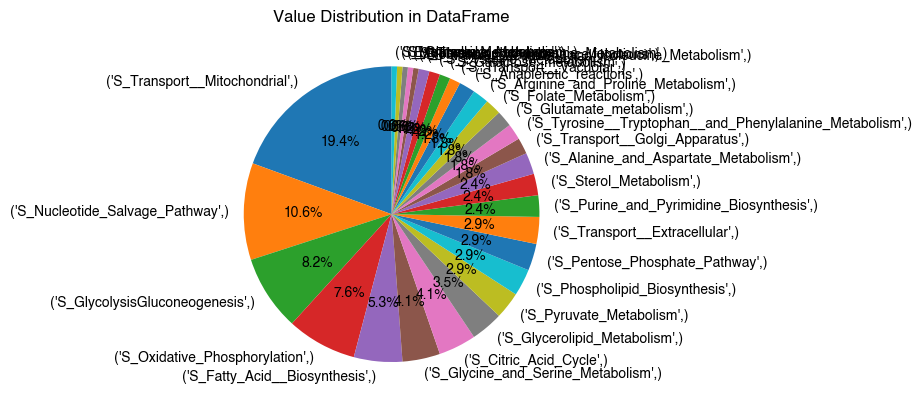

In [82]:
counts=df_diff_rxn.value_counts()
fig, ax = plt.subplots()
counts.plot.pie(
    autopct='%1.1f%%',      # percentage format
    startangle=90,          # rotate so first slice starts at top
    labels=counts.index,    # use -1, 0, 1 as labels
    # colors=["#ff9999","#99ff99","#9999ff"],  # custom colors
    ax=ax
)
ax.set_ylabel("")  # remove y-label
ax.set_title("Value Distribution in DataFrame")
plt.show()